# Explore here

In [45]:
#LIBRERÍAS A UTILIZAR

import pandas as pd


In [46]:
df = pd.read_csv('https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv', sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [47]:
df.shape

(41188, 21)

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [49]:
categoricas = df.select_dtypes(include=['str']).columns.tolist() # Esta función sirve para obtener las columnas de algún tipo

categoricas

# Y así obtenemos las que son de tipo 'str'

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']

In [50]:
# Y para obtener las numéricas es un proceso casi igual:

numericas = df.select_dtypes(exclude=['str']).columns.tolist()

numericas

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [51]:
# Antes de empezar a tocar estas columnas y empezar a trabajar en ellas, lo primero que tenemos que hacer es ver si hay duplicados:

df.duplicated().sum()

np.int64(12)

In [52]:
# si tenemos filas duplicadas entonces:

if df.duplicated().sum():
    df.drop_duplicates(inplace= True)

df.shape

# Con esto, quitamos las 12 duplicadas.

(41176, 21)

In [53]:
# Vamos a hacer un FOR para transformar variables categóricas en numéricas:

for columna in categoricas:
    df[columna] = pd.factorize(df[columna])[0]

df.info()

# Y todas se transforman en numéricas.

<class 'pandas.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  int64  
 2   marital         41176 non-null  int64  
 3   education       41176 non-null  int64  
 4   default         41176 non-null  int64  
 5   housing         41176 non-null  int64  
 6   loan            41176 non-null  int64  
 7   contact         41176 non-null  int64  
 8   month           41176 non-null  int64  
 9   day_of_week     41176 non-null  int64  
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  int64  
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  float64
 18  eu

In [54]:
df.head()

# El NO quedó como 0, y el SÍ quedó como 1. Tenemos 20 predictoras, es un modelo grande en sí, pero no necesariamente todas las columnas van a servir, y eso lo vemos con un EDA. 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,0,0,0,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
1,57,1,0,1,1,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
2,37,1,0,1,0,1,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
3,40,2,0,2,0,0,0,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0
4,56,1,0,1,0,0,1,0,0,0,...,1,999,0,0,1.1,93.994,-36.4,4.857,5191.0,0


# AQUÍ VA EL EDA (HACERLO SOLITOS)

El fin es crear un algoritmo de clasificación que ayude a **predecir si un cliente contratará o no un depósito a largo plazo**.

Variable objetivo: 'y'


## 1. Eliminar información irrelevante:

**Debemos responder a la siguiente pregunta: ¿son todas las características imprescindibles para realizar una predicción? Normalmente, esa pregunta es un rotundo no.**

En este caso en particular, considero que todas las variables son dignas de analizarse, porque todas están relacionadas con el problema. No existen índices ni nombres, ni ID, que no tengan que ver con un préstamo o con el contacto del cliente, por ende no descartaremos ninguna.

## 2. Eliminamos duplicados: 
A este paso lo realizamos con anterioridad. 

## 3. Análisis de variables univariante:

Esto es el análisis columna a columna del DataFrame. Para ello, debemos distinguir si una variable es categórica o numérica, ya que el análisis y las conclusiones que se pueden obtener serán distintas.

In [55]:
numericas = ['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']


categoricas = ['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'poutcome',
 'y']


Análisis de variables CATEGÓRICAS:

Para representar este tipo de variables utilizaremos histogramas o gráficos de barras verticales.

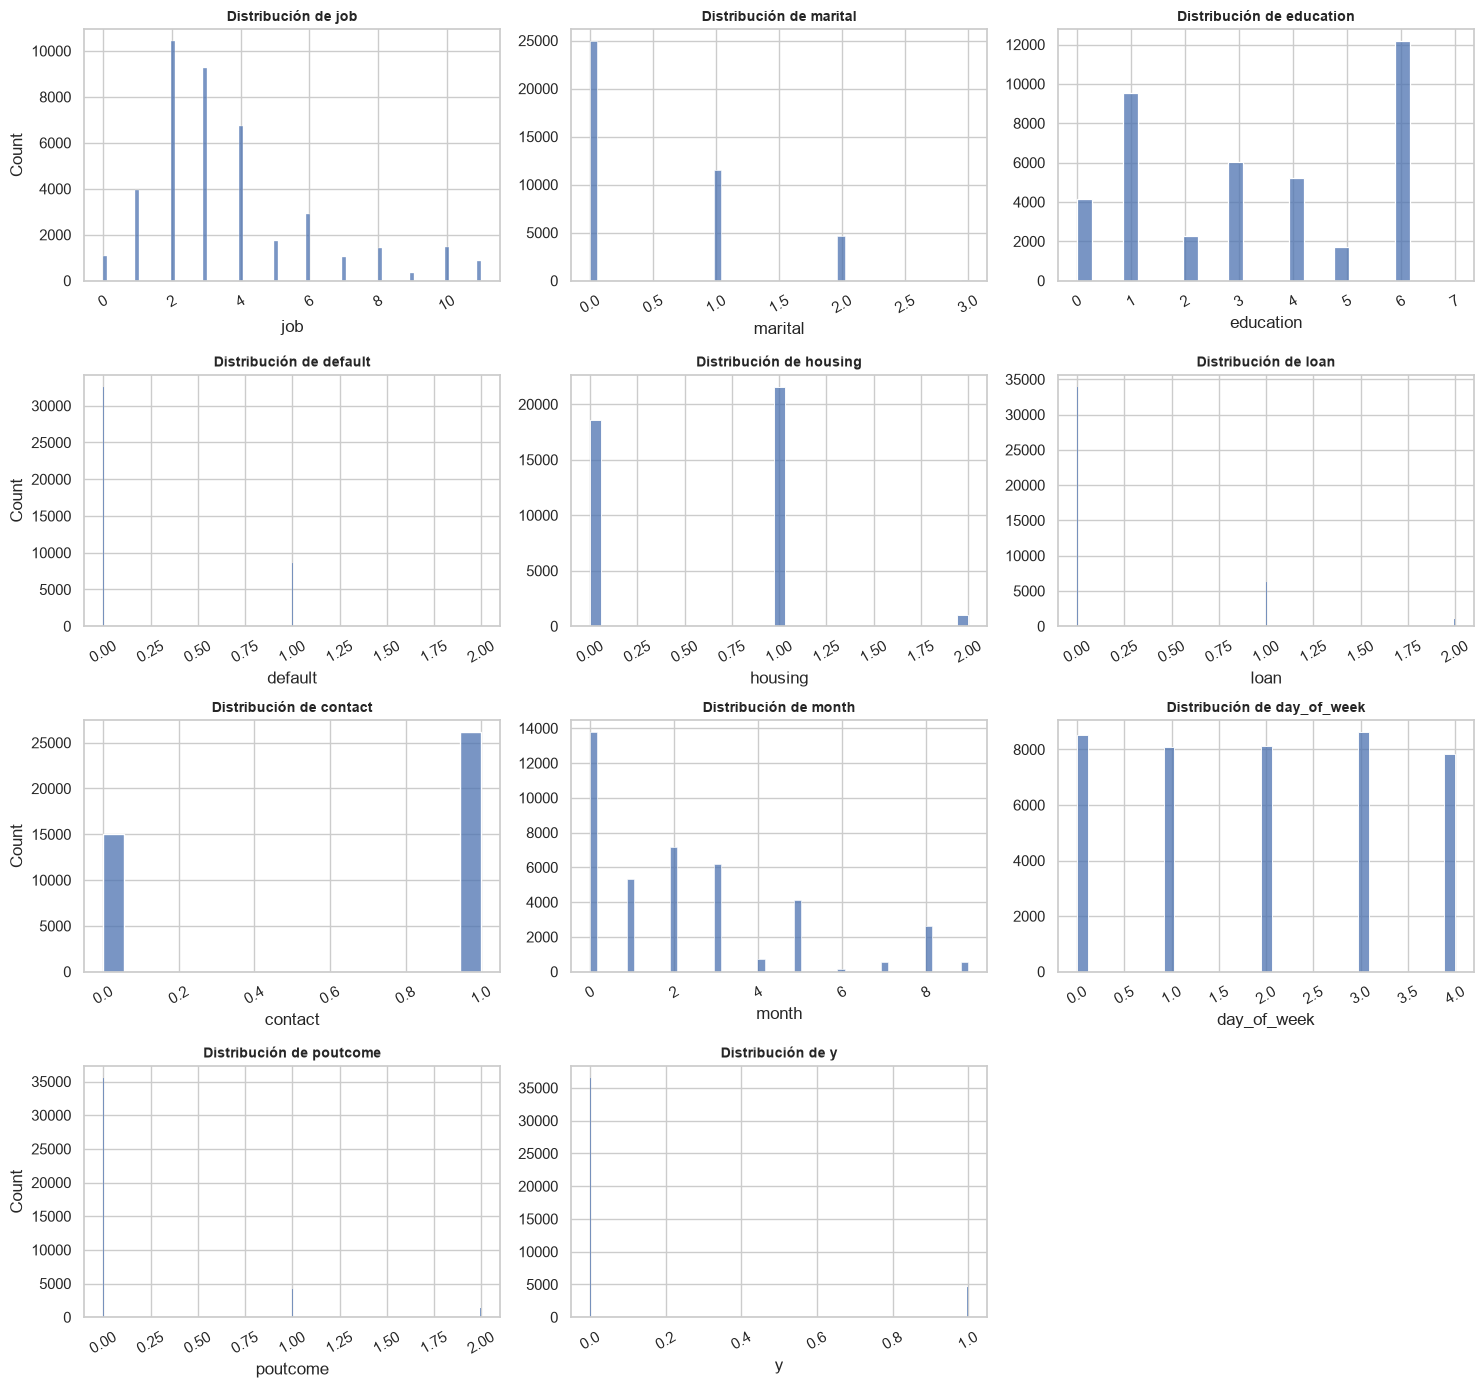

In [56]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la retícula: 3 columnas
ncols = 3
num_vars = len(categoricas)
nrows = math.ceil(num_vars / ncols)  # Dará 4 filas (4x3 = 12 espacios)

fig, axis = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 14))

# Bucle para graficar automáticamente cada variable de la lista
for i, col in enumerate(categoricas):
    row = i // ncols
    c = i % ncols
    ax = axis[row, c]
    
    # Crear histograma para cada variable
    sns.histplot(ax=ax, data=df, x=col)
    ax.set_title(f'Distribución de {col}', fontsize=10, fontweight='bold')
    
    # Rotar las etiquetas del eje X si tienen nombres largos para evitar solapamiento
    ax.tick_params(axis='x', rotation=30)
    
    # Opcional: eliminar la etiqueta repetitiva de 'Count' salvo en la primera columna
    if c != 0:
        ax.set(ylabel=None)

# Ocultar los subgráficos sobrantes (las celdas 11 y 12 que quedan vacías)
for j in range(num_vars, nrows * ncols):
    row = j // ncols
    c = j % ncols
    fig.delaxes(axis[row, c])

plt.tight_layout()
plt.show()

**Conclusiones de las variables categóricas según sus distribuciones en los gráficos:**

job (Ocupación): Gran concentración laboral. Tres perfiles resumen casi todo el volumen: administrativos (admin.), operarios (blue-collar) y técnicos. Sectores como estudiantes o jubilados son testimoniales.

marital (Estado Civil): Dominio absoluto de personas casadas (married), representando más del 50% de la base total. Los solteros son el segundo grupo en relevancia y los divorciados una minoría.

education (Nivel Educativo): Perfil educativo medio-alto. La mayoría posee título universitario o secundaria completa. Los niveles de educación primaria básica representan una porción pequeña del total.

default (Crédito en Mora): Variable sin varianza útil. La inmensa mayoría casi absoluta es no y el resto son valores no informados (unknown). Prácticamente no existen registros confirmados de clientes en mora (yes).

housing (Préstamo Hipotecario): Distribución equilibrada. La muestra se divide casi en partes iguales (50/50) entre quienes tienen una hipoteca activa y quienes no.

loan (Préstamo Personal): Baja penetración. Al contrario de la vivienda, la gran mayoría de los clientes no posee préstamos personales vigentes.

contact (Medio de Contacto): Preferencia por la telefonía móvil. Las llamadas a teléfono celular superan sustancialmente a las realizadas a teléfonos fijos tradicionales.

month (Mes de Contacto): Fuerte estacionalidad en la operativa. Mayo (may) concentra un pico masivo de llamadas, seguido por el período estival. Los meses de primavera/otoño registran muy pocos contactos.

day_of_week (Día de la Semana): Distribución completamente uniforme. La carga de contactos se reparte de forma homogénea (~20% diario) entre los cinco días laborables (lunes a viernes).

poutcome (Resultado de Campaña Anterior): Predominio de clientes nuevos. Domina abrumadoramente la categoría nonexistent, lo que indica que para la gran mayoría de la base es el primer contacto comercial y no existen antecedentes de campañas pasadas.


**Podemos decir que variables como 'default' y 'day_of_week' no aportarían información relevante a nuestro modelo predictivo ya que prácticamente no existen registros confirmados de clientes en mora, y por otro lado, la distribución de las llamadas en los días de la semana es uniforme (de Lunes a Viernes), es decir, los contactos a clientes se reparten homogéneamente en los 5 días hábiles de la semana.**

Análisis de variables NUMÉRICAS:

Normalmente se representan utilizando un histograma y diagramas de caja, expuestos juntos.

In [57]:
numericas = ['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

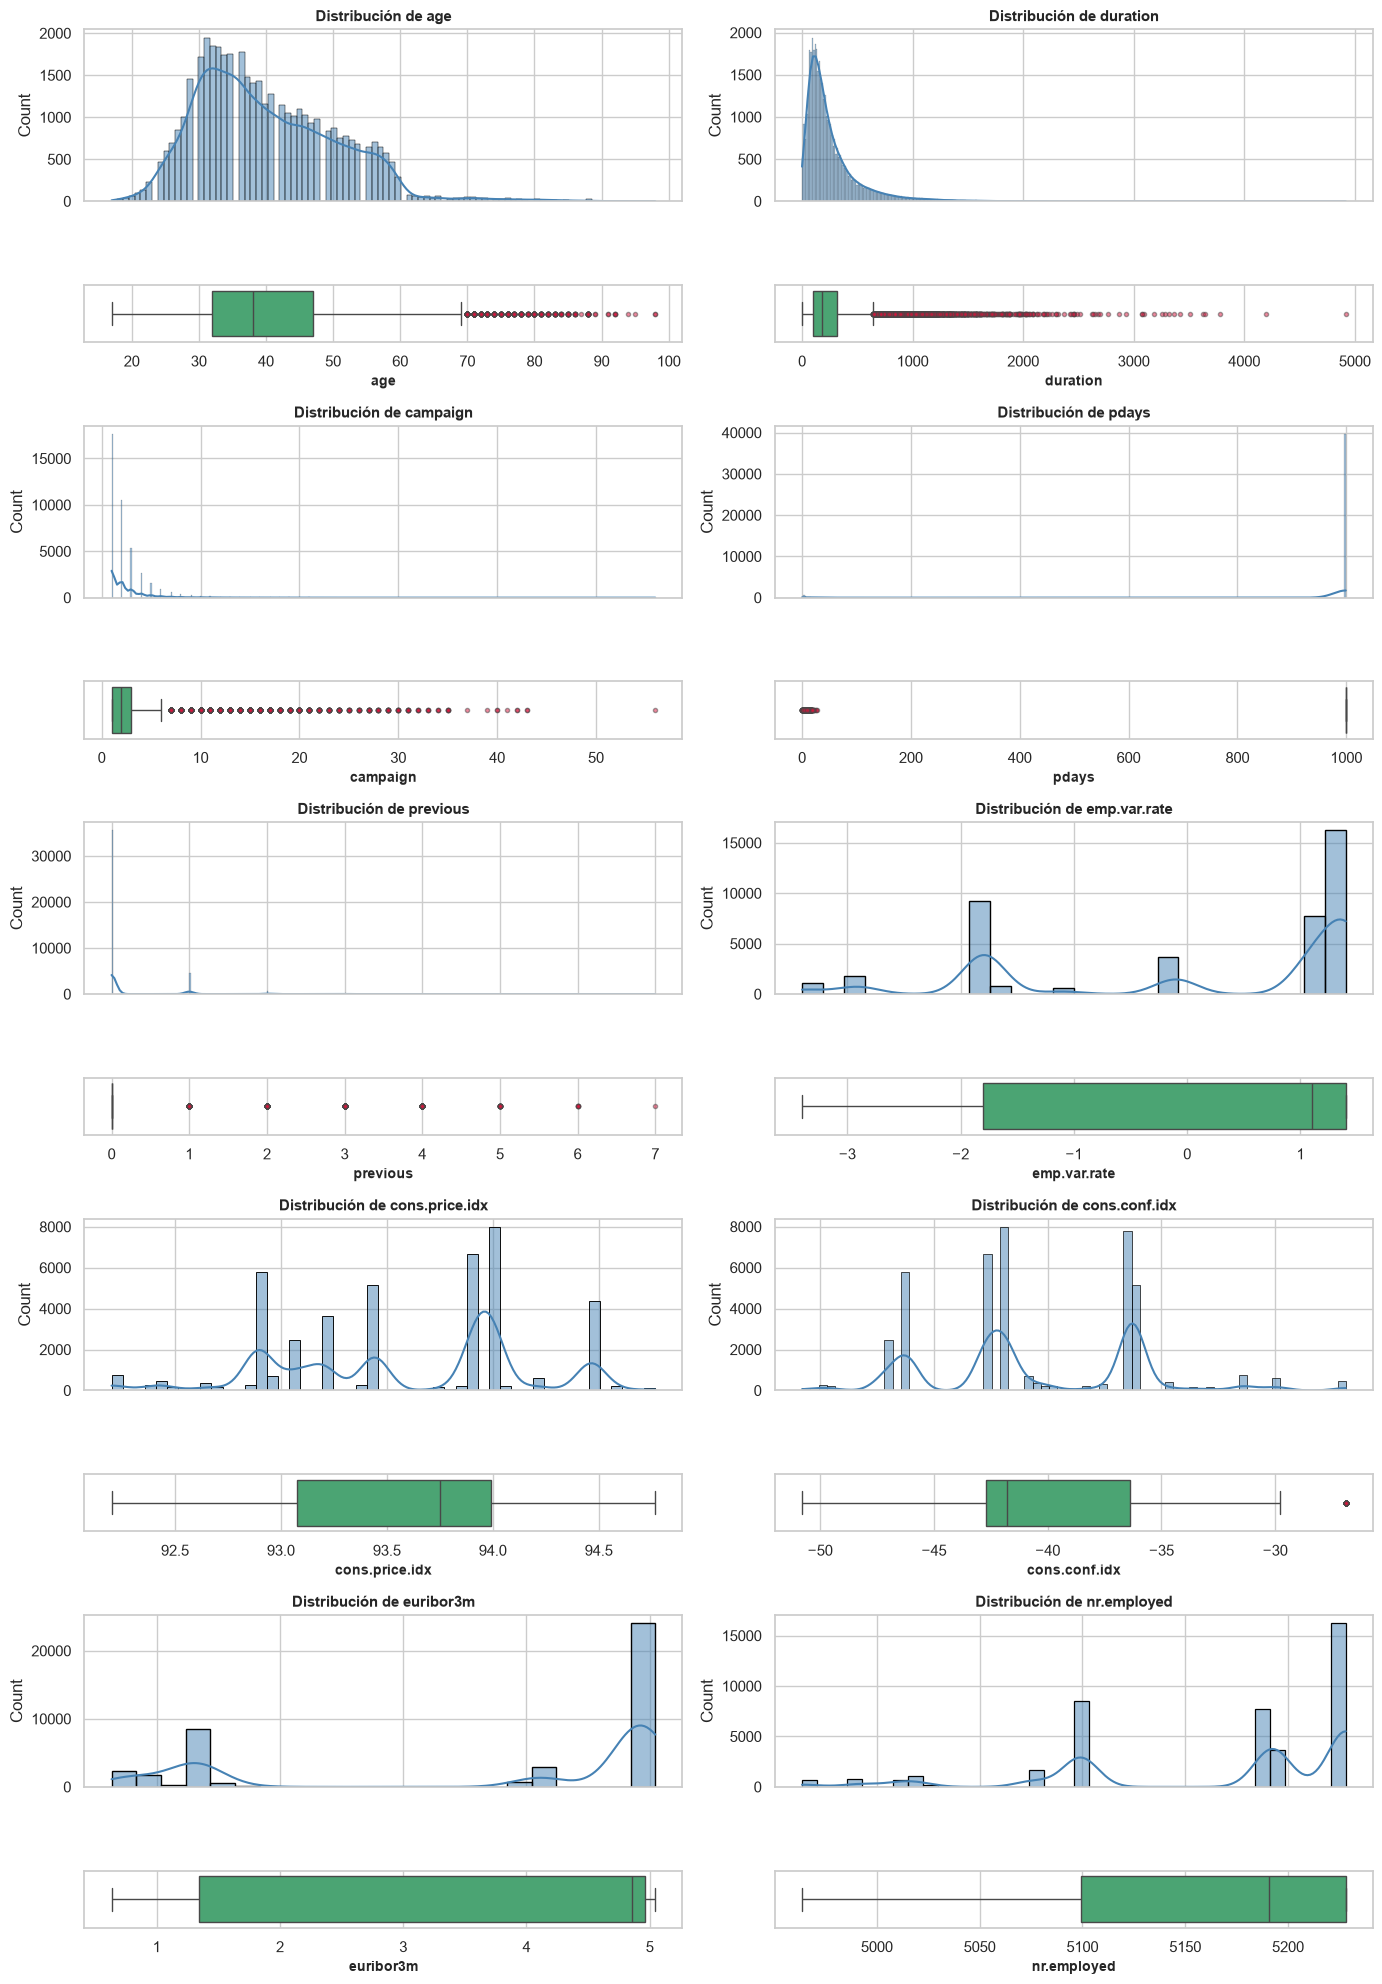

In [58]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Configuración de la retícula: 2 columnas x 5 bloques de variables
ncols = 2
num_vars = len(numericas)
num_bloques = math.ceil(num_vars / ncols)  # 5 bloques verticales

# Se crean 10 filas en total (2 filas por cada variable: 1 Histograma + 1 Boxplot)
fig, axes = plt.subplots(
    nrows=num_bloques * 2, 
    ncols=ncols, 
    figsize=(14, 4 * num_bloques), 
    gridspec_kw={'height_ratios': [3, 1] * num_bloques} # El histograma es más alto que el boxplot
)

# Bucle para graficar histograma + boxplot por cada variable
for i, col in enumerate(numericas):
    row_hist = (i // ncols) * 2  # Fila para el histograma
    c = i % ncols               # Columna (0 o 1)
    row_box = row_hist + 1       # Fila inmediatamente inferior para el boxplot
    
    ax_hist = axes[row_hist, c]
    ax_box = axes[row_box, c]
    
    # 1. Histograma (Arriba)
    sns.histplot(
        data=df, x=col, kde=True, ax=ax_hist, 
        color='steelblue', edgecolor='black'
    )
    ax_hist.set_title(f'Distribución de {col}', fontsize=11, fontweight='bold')
    ax_hist.set_xlabel('')
    ax_hist.tick_params(labelbottom=False)  # Oculta etiquetas numéricas repetidas en X
    
    # 2. Diagrama de caja / Boxplot (Abajo)
    sns.boxplot(
        data=df, x=col, ax=ax_box, color='mediumseagreen',
        flierprops=dict(marker='o', markerfacecolor='crimson', markersize=3, alpha=0.5)
    )
    ax_box.set_xlabel(col, fontsize=10, fontweight='bold')
    
    # Compartir el mismo eje X para asegurar alineación visual perfecta
    ax_hist.sharex(ax_box)

plt.tight_layout()
plt.show()

**Conclusiones de las variables Numéricas según sus distribuciones en los gráficos presentados:**

age: Concentrada entre 30 y 50 años (la media está entre 38 y 40 años), con atípicos en adultos mayores (>60 años).

duration: Sesgada a la derecha; llamadas cortas en su gran mayoría con atípicos aislados muy largos.

campaign: Casi todos reciben de 1 a 3 contactos, pero hay atípicos de persistencia extrema (>10) (demasiada insistencia).

pdays: Bimodal extrema; concentrada en 999 (sin contacto previo en campañas anteriores).

previous: Domina el 0; casi no hay registros con múltiples contactos previos.

emp.var.rate: Distribución bimodal dividida entre períodos de destrucción y creación de empleo.

cons.price.idx: Agrupada en bloques discretos correspondientes a distintos niveles de inflación.

cons.conf.idx: Distribución simétrica en valores negativos (confianza del consumidor baja/moderada).

euribor3m: Bimodal muy marcada; los datos se dividen entre tasas muy bajas (~1.2%) y altas (~4.8%).

nr.employed: Agrupada en niveles altos (>5000 empleados), reflejando la plantilla laboral en el tiempo.

**Podemos identificar dos variables que podríamos descartar: 'pdays' (ya que casi el 100% de los datos se agrupan en el valor numérico codificado 999) y 'emp.var.rate' (o en su defecto 'euribor3m') ya que tienen una correlación lineal extremadamente alta, y medir la variación del empleo y la tasa Euribor simultáneamente introduce multicolinealidad severa en modelos probabilísticos y lineales. Se recomienda conservar euribor3m (que suele tener mayor fuerza explicativa del entorno económico) y descartar 'emp.var.rate'.**

## 4. Análisis de variables multivariante. Análisis numérico-numérico.


Tras analizar las características una a una, es momento de analizarlas en relación con la predictora y con ellas mismas, para sacar conclusiones más claras acerca de sus relaciones y poder tomar decisiones sobre su procesamiento.


### Análisis numérico-numérico

 Para comparar dos columnas numéricas se utilizan diagramas de dispersión y análisis de correlaciones.

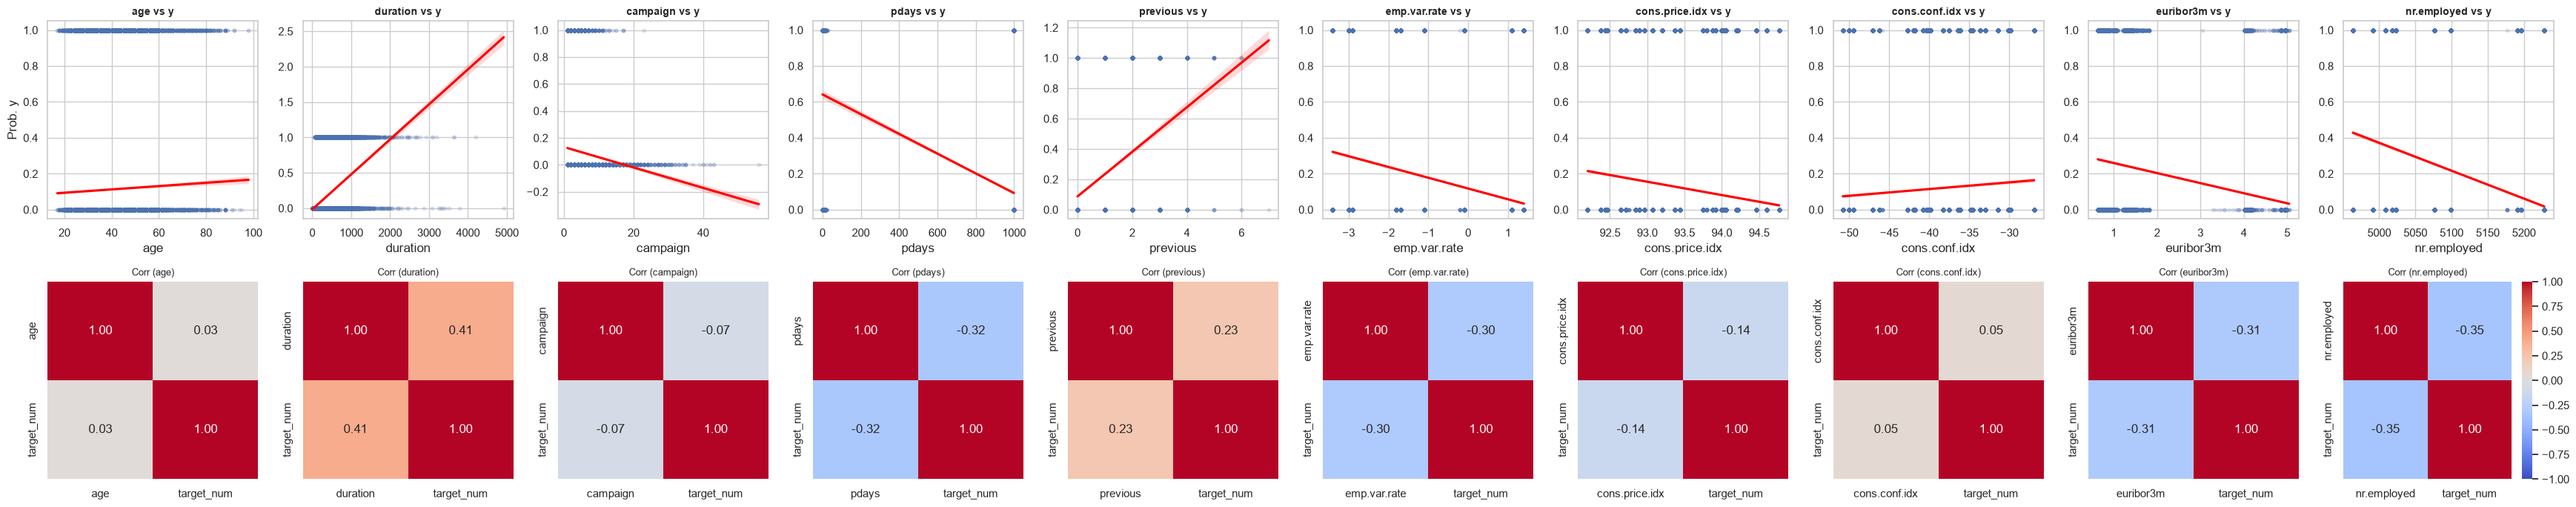

In [59]:
# Variable objetivo / clase (ajusta si en tu DataFrame se llama 'y' o 'Survived')
target_col = 'y' 

# 2. Convertir la variable objetivo a numérica (1 / 0) si es categórica ('yes'/'no')
df_plot = df.copy()
if df_plot[target_col].dtype == 'object':
    df_plot['target_num'] = df_plot[target_col].map({'yes': 1, 'no': 0})
else:
    df_plot['target_num'] = df_plot[target_col]

# 3. Graficar en un solo panel ordenado
ncols = len(numericas) # 10 columnas
fig, axis = plt.subplots(2, ncols, figsize=(3.5 * ncols, 7))

for i, col in enumerate(numericas):
    # Fila 0: Diagrama de Regresión / Dispersión
    sns.regplot(
        data=df_plot, 
        x=col, 
        y='target_num', 
        ax=axis[0, i],
        scatter_kws={'alpha': 0.15, 's': 10},
        line_kws={'color': 'red'}
    )
    axis[0, i].set_title(f'{col} vs {target_col}', fontsize=10, fontweight='bold')
    axis[0, i].set_xlabel(col)
    axis[0, i].set_ylabel(f'Prob. {target_col}' if i == 0 else '')
    
    # Fila 1: Heatmap de Correlación individual
    corr_matrix = df_plot[[col, 'target_num']].corr()
    
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        vmin=-1, vmax=1, 
        ax=axis[1, i], 
        cbar=(i == ncols - 1) # Barra de color solo en la última columna
    )
    axis[1, i].set_title(f'Corr ({col})', fontsize=9)

plt.tight_layout()
plt.show()

**Conclusiones: (Del análsis de cada variable categórica con la variable objetivo)**

**La variable 'duration' tiene un acorrelación de 0.41 con la variable objetivo, es super alta. También las variables 'pdays' (-0.32), 'previous' (0.23), 'emp.var.rate'(-0.30), 'euribor3m' (-0.31),'nr.employed'(-0.35).**

**Variables con Mayor Impacto (Correlaciones Directas / Relevantes)**

duration: Es la variable con la correlación positiva más fuerte. A pesar de que la gran mayoría de las llamadas son muy cortas, cuanto más dura la llamada, mayor es la probabilidad de que el cliente se suscriba.

nr.employed: Correlación negativa fuerte. A mayor número de empleados en el contexto socioeconómico, menor es la tasa de suscripción. A menor empleados, mayor posibilidades de suscripción.

pdays: Correlación negativa moderada. Como el valor 999 indica "no contactado previamente", un pdays alto reduce la probabilidad de éxito. Tiene sentido, a menor contacto previo, menor correlación con la variable objetivo. 

euribor3m y emp.var.rate: Correlaciones negativas moderadas. Un entorno macroeconómico con tasas de interés elevadas y alta tasa de variación de empleo desincentiva las suscripciones. A mayor tasa menor correlación con 'y'. (Recordemos que 'emp.var.rate' y 'euribor3m' tienen una correlación lineal extremadamente alta, y medir la variación del empleo y la tasa Euribor simultáneamente introduce multicolinealidad severa en modelos probabilísticos y lineales. Asique vamos a descartar 'emp.var.rate' como lo vimos anteriormente. )

previous: Correlación positiva moderada. Cuantos más contactos previos haya tenido el cliente en campañas pasadas, mayor es su predisposición a aceptar. Aumenta la posibilidad a medida de que los llamados previos que hay atenido el cliente sean más numerosos. 

**Variables con Impacto Débil o Casi Nulo**

cons.price.idx: Correlación negativa leve; el índice de precios al consumidor apenas afecta la decisión. 

campaign: Correlación negativa mínima; la cantidad de contactos en la campaña actual casi no altera la respuesta final (sólo demuestra un leve desgaste si es muy insistente).

cons.conf.idx: Correlación positiva casi nula; la confianza del consumidor no influye de forma directa.

age: Correlación prácticamente nula ($0.03$); la edad en sí misma no tiene relación lineal directa con la conversión del cliente.

**A continuación también podemos relacionar estas variables que resaltan para determinar su grado de afinidad o correlación:**

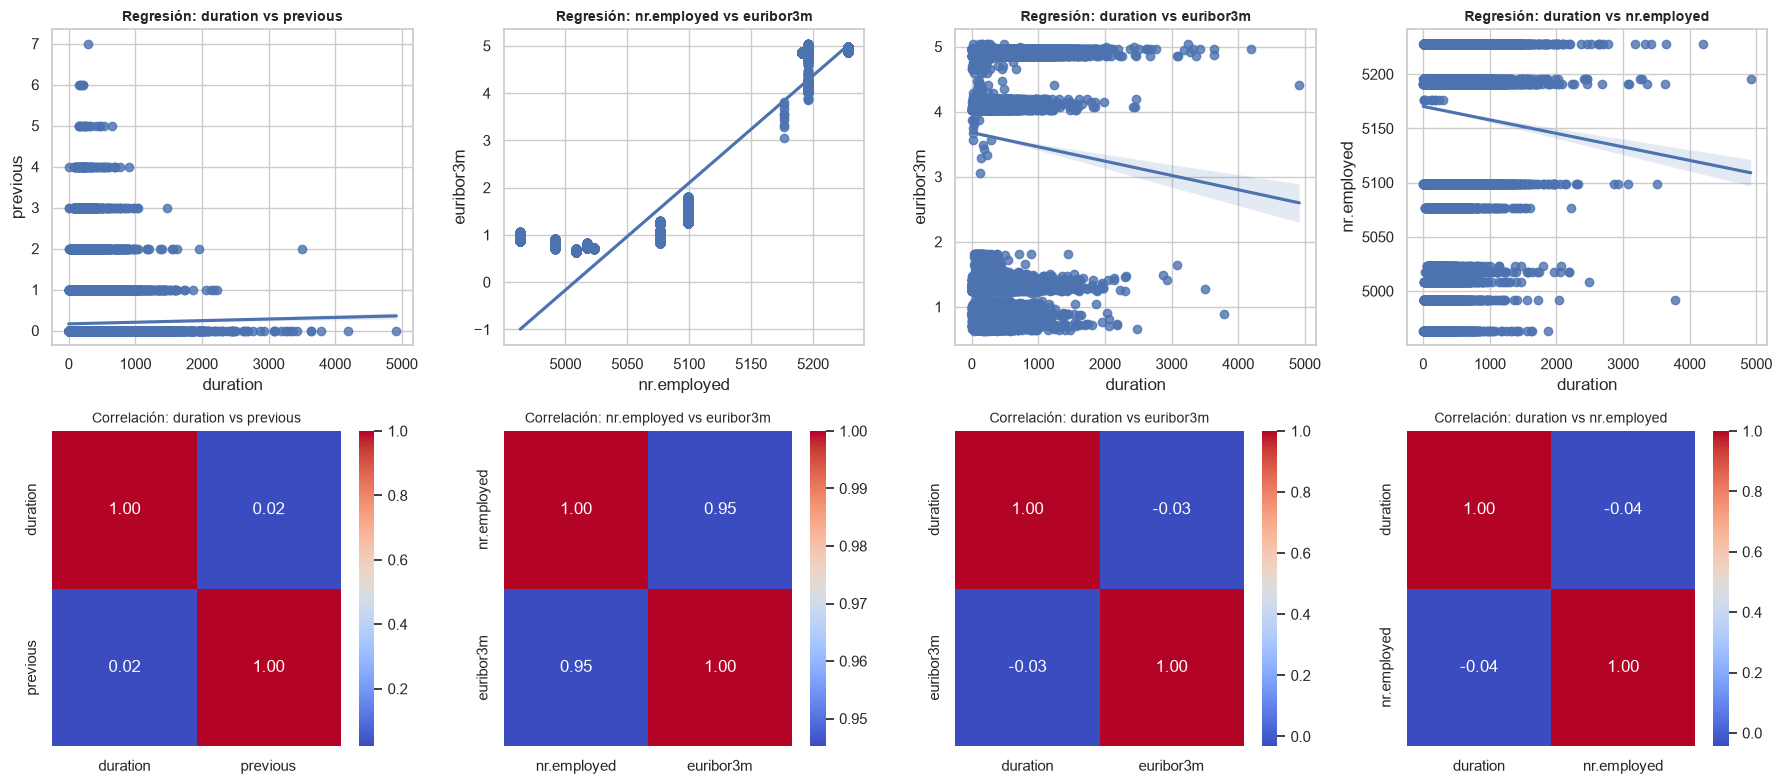

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las parejas de variables (x, y)
pares = [
    ('duration', 'previous'),
    ('nr.employed', 'euribor3m'),
    ('duration', 'euribor3m'),
    ('duration', 'nr.employed')
]

fig, axis = plt.subplots(2, len(pares), figsize=(4.5 * len(pares), 8))

for i, (var_x, var_y) in enumerate(pares):
    # Fila 0: Diagrama de Regresión
    sns.regplot(ax=axis[0, i], data=df, x=var_x, y=var_y)
    axis[0, i].set_title(f'Regresión: {var_x} vs {var_y}', fontsize=10, fontweight='bold')
    
    # Fila 1: Heatmap de Correlación
    sns.heatmap(df[[var_x, var_y]].corr(), annot=True, fmt=".2f", ax=axis[1, i], cmap="coolwarm")
    axis[1, i].set_title(f'Correlación: {var_x} vs {var_y}', fontsize=10)

plt.tight_layout()
plt.show()

De la relación entre estas variables podemos determinar el grado de relación directa y lógica que hay entre 'euriborn' u nr.employed'ya que, en un entorno macroeconómico con tasas de interés bajas y baja tasa de variación de empleo, aumenta radicalmente el número de contrataciones/empleados. Muestran una clara tendencia: cuando las tasas de interés, la variación del empleo y la plantilla laboral son bajas, aumentan las contrataciones y por ende los empleados. 

Por otro lado, con respecto a 'previous' y 'duration' no hay relación prácticamente, no hay relación entre el número de contactos realizados en la campaña anterior y la duración de los mismos. 

y entre 'duration' con las variables'euribor3m' y 'nr.employed' tampoco hay una correlación importante.

### Análisis categórico-categórico

In [61]:
# Antes del modelo, tengo que definir mis x de train y de test:

x = df.drop(columns=['y'])
y= df['y']

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

In [62]:
# Tenemos que hacer la normalización de los datos (chequear si usamos el "standar" si sé que mis datos distribuyen normal, si no lo sé, voy a usar minmax) Asique en este caso lo vamos a hacer con minmax porque todavía no hacemos el Eda y estamos como ciegos. Luego que de que hagan el EDa pueden tomar una mejor decisión.

from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

x_train_esc = scaler.fit_transform(x_train)

x_train_esc = pd.DataFrame(x_train_esc, columns= x_train.columns, index= x_train.index)

x_test_esc = scaler.transform(x_test)

x_test_esc = pd.DataFrame(x_test_esc, columns =x_test.columns, index= x_test.index)




In [63]:
x_train_esc.head() # para que los podamos ver. Y ahí ya están escalados los datos.

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
12348,0.148148,0.909091,0.000000,0.285714,0.0,0.5,0.5,0.0,0.222222,1.00,0.058154,0.036364,1.0,0.0,0.0,1.000000,0.669135,0.338912,0.980503,1.000000
8565,0.407407,0.181818,0.333333,0.857143,0.0,0.0,0.0,0.0,0.111111,0.50,0.036194,0.090909,1.0,0.0,0.0,1.000000,0.882307,0.376569,0.958966,1.000000
21424,0.148148,0.181818,0.333333,0.857143,0.0,0.0,0.0,1.0,0.333333,0.25,0.020943,0.054545,1.0,0.0,0.0,1.000000,0.484412,0.615063,0.981410,1.000000
3316,0.222222,0.181818,0.333333,0.857143,0.0,0.0,0.0,0.0,0.000000,0.75,0.027450,0.000000,1.0,0.0,0.0,0.937500,0.698753,0.602510,0.958059,0.859735
33246,0.283951,0.272727,0.333333,0.142857,0.5,0.0,0.0,1.0,0.000000,0.25,0.084994,0.000000,1.0,0.0,0.0,0.333333,0.269680,0.192469,0.148946,0.512287


In [64]:
# Una vez que todas las columnas son numéricas y están escaladas, podemos pensar en hacer una REGRESIÓN LOGÍSTICA:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_esc, y_train)

# Y tenemos todos los hiperparámetros que está utilizando el modelo por defecto. Y tmb podemos ver los atributos del modelo, que es lo que usó para hacer las predicciones.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [65]:
# Hasta acá ya tengo un modelo entrenado sobre mis x de entrenamiento (x_train). 
# Ahora lo que necesito son resultados. 

y_pred = model.predict(x_test_esc)
y_pred

# ¿Cómo se va an a ver? En este caso es un Array de 8.236 de largo, que es el 20% + o - de los 41 mil casos que tengo, y voy a ver un conjunto de unos y ceros. Esto sólo me dice que ya el modelo hizo predicciones. 

array([1, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [66]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

# Acá comparamos los y de test con los y predichos. 
# y nos dice que este modelo (sin el EDA realizado todavía) tiene un 90.23 % de probabilidad de acertar. Si yo ahora analizo un nuevo cliente, mi modelo va a ser capaz de predecir en un 90% si ese cliente va a tomar o no va a tomar un crédito. 

0.9023797960174842

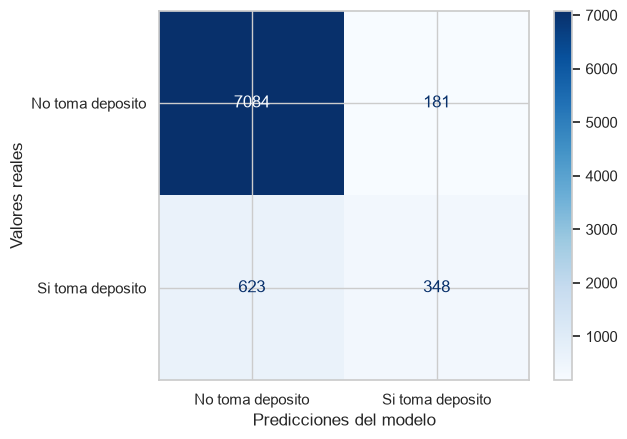

In [67]:
# Matríz de confusión

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp= ConfusionMatrixDisplay (cm, display_labels=['No toma deposito', 'Si toma deposito'])

disp.plot(cmap=plt.cm.Blues)

plt.xlabel('Predicciones del modelo')
plt.ylabel('Valores reales')
plt.show()


# En el EDA tenemos que mejorar todavía más el modelo.

In [68]:
# Una vez que ya tengo el modelo base, ya podemos hacer la búsqueda de hiperparámetros

from sklearn.model_selection import GridSearchCV
import numpy as np

param_grid = {
    'penalty' : ['l1', 'l2', 'elasticnet', None],
    'C': [0.001, 0.01, 0.1, 10.0, 100.0, 1000.0],
    'solver': ['saga'],
    'l1_ratio': [0.5],
    'max_iter': [2000]
}

grid_search = GridSearchCV (
    estimator = model,
    param_grid= param_grid,
    cv = 5,
    scoring ='accuracy',
    n_jobs= -1
)


In [69]:
# Ahí está definida la grilla, ahora hay que entrenarla

grid_search.fit(x_train_esc, y_train)


C:\Users\brend\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\brend\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
C:\Users\brend\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'l1_ratio': [0.5], 'max_iter': [2000], 'penalty': ['l1', 'l2', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Con

In [70]:
print(grid_search.best_params_)

{'C': 1000.0, 'l1_ratio': 0.5, 'max_iter': 2000, 'penalty': 'l2', 'solver': 'saga'}


In [71]:
mejor_modelo = grid_search.best_estimator_

y_pred_mejor = mejor_modelo.predict(x_test_esc)
accuracy_score(y_test, y_pred_mejor)

# No es una gran mejora la que obtuvimos, pero mejoró a 90.38 %. 

0.9038368139873725